# European Soccer Player Market Value
This workbook contains EDA, feature engineering, and modeling of European soccer player performance statistics and market values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_profiles = pd.read_csv('data/all_player_profiles.csv')
df_stats = pd.read_csv('data/all_player_stats.csv')

## EDA and Data Cleaning

In [3]:
df_profiles.head()

,player_id,name,league,position,market_value
0,804508,Viktor Gyökeres,Premier League,F,61000000.0
1,934235,Bukayo Saka,Premier League,F,126000000.0
2,794839,Gabriel Jesus,Premier League,F,21000000.0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0
4,836705,Kai Havertz,Premier League,F,48000000.0


In [4]:
df_stats.head()

,player_id,league,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Premier League,29,23,1907,11,0,9.3498,1.767505,6.572414,43,17,4,0,6,1,0
1,934235,Premier League,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Premier League,11,2,306,2,0,1.7605,0.203329,6.527273,14,9,2,0,4,2,0
3,922573,Premier League,25,9,852,1,3,3.3793,0.991020,6.616000,25,10,2,0,10,0,0
4,836705,Premier League,6,3,264,0,1,0.3077,0.097873,6.650000,5,1,0,0,3,0,0


In [5]:
df = pd.merge(df_profiles, df_stats, on='player_id', how='inner')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3725 entries, 0 to 3724
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3725 non-null   int64  
 1   name              3725 non-null   object 
 2   league_x          3725 non-null   object 
 3   position          3725 non-null   object 
 4   market_value      3660 non-null   float64
 5   league_y          3725 non-null   object 
 6   appearances       3725 non-null   int64  
 7   matches_started   3725 non-null   int64  
 8   minutes_played    3725 non-null   int64  
 9   goals             3725 non-null   int64  
 10  assists           3725 non-null   int64  
 11  expected_goals    3161 non-null   float64
 12  expected_assists  3701 non-null   float64
 13  rating            3725 non-null   float64
 14  total_shots       3725 non-null   int64  
 15  shots_on_target   3725 non-null   int64  
 16  yellow_cards      3725 non-null   int64  


In [7]:
# Sanity check to ensure that both data sets have the same player in the same league.
mismatched_leagues = df[df['league_x'] != df['league_y']]
print(f"Rows with mismatched leagues: {len(mismatched_leagues)}")

Rows with mismatched leagues: 0


In [8]:
df = df.drop(columns=['league_y']).rename(columns={'league_x':'league'})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3725 entries, 0 to 3724
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3725 non-null   int64  
 1   name              3725 non-null   object 
 2   league            3725 non-null   object 
 3   position          3725 non-null   object 
 4   market_value      3660 non-null   float64
 5   appearances       3725 non-null   int64  
 6   matches_started   3725 non-null   int64  
 7   minutes_played    3725 non-null   int64  
 8   goals             3725 non-null   int64  
 9   assists           3725 non-null   int64  
 10  expected_goals    3161 non-null   float64
 11  expected_assists  3701 non-null   float64
 12  rating            3725 non-null   float64
 13  total_shots       3725 non-null   int64  
 14  shots_on_target   3725 non-null   int64  
 15  yellow_cards      3725 non-null   int64  
 16  red_cards         3725 non-null   int64  


In [10]:
df = df.set_index('player_id')
df.shape

(3725, 19)

In [11]:
df.describe()

,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
count,3.660000e+03,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3161.000000,3.701000e+03,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000
mean,9.917490e+06,17.186309,12.404832,1115.761074,1.515168,1.062013,1.841740,1.101702e+00,6.718248,14.150604,4.876510,2.193020,0.114899,17.884832,9.383356,3.423087
std,1.656789e+07,8.668354,9.063707,768.761711,2.610213,1.644628,2.433426,1.360329e+00,0.636513,16.139484,6.635014,2.102133,0.344834,16.660214,9.990148,15.293558
min,2.300000e+04,1.000000,0.000000,1.000000,0.000000,0.000000,0.003200,9.300000e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.100000e+06,10.000000,4.000000,436.000000,0.000000,0.000000,0.360300,1.433916e-01,6.600000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,3.700000e+06,19.000000,11.000000,1038.000000,1.000000,0.000000,0.992300,6.322265e-01,6.741667,9.000000,2.000000,2.000000,0.000000,14.000000,6.000000,0.000000
75%,1.160000e+07,25.000000,20.000000,1755.000000,2.000000,2.000000,2.217400,1.530088e+00,6.906897,20.000000,7.000000,3.000000,0.000000,28.000000,15.000000,0.000000
max,2.180000e+08,31.000000,31.000000,2790.000000,31.000000,18.000000,24.383200,1.476492e+01,9.700000,117.000000,61.000000,12.000000,3.000000,96.000000,63.000000,138.000000


In [12]:
df['league'].value_counts()

league
LaLiga            515
Serie A           495
Premier League    477
Eredivisie        459
Liga Portugal     453
Ligue 1           447
Super Lig         442
Bundesliga        437
Name: count, dtype: int64

The data is fairly evently distributed across the leagues.

In [13]:
df['position'].value_counts()

position
M    1449
D    1223
F     781
G     272
Name: count, dtype: int64

There are less rows for goalies than other positions by a significant factor.

In [14]:
df.isnull().sum()

name                  0
league                0
position              0
market_value         65
appearances           0
matches_started       0
minutes_played        0
goals                 0
assists               0
expected_goals      564
expected_assists     24
rating                0
total_shots           0
shots_on_target       0
yellow_cards          0
red_cards             0
tackles               0
interceptions         0
saves                 0
dtype: int64

In [15]:
# Drop name as it won't be used for modeling
df = df.drop(columns=['name'])

A significant number of rows have missing `expected_goals`, too many to drop from the data set.  We will instead fill in the missing data.

In [16]:
# Fill expected goals with per-position median.  This would be slightly more accurate than 
# a global median because goalies should have a lower exected goals value than forwards.
df['expected_goals'] = df.groupby('position')['expected_goals'].transform(
    lambda x: x.fillna(x.median())
)
# Fill exptected assists with per-position median for the same reason as above.
df['expected_assists'] = df.groupby('position')['expected_assists'].transform(
    lambda x: x.fillna(x.median())
)

In [17]:
# Drop rows with missing market value because this is our target. These rows are useless.
df = df.dropna(subset=['market_value'])

In [18]:
# Drop rows with less than 270 minutes played.  These players' stats will most likely introduce more noise than anything.
df = df[df['minutes_played'] >= 270]

In [19]:
df.shape

(3058, 18)

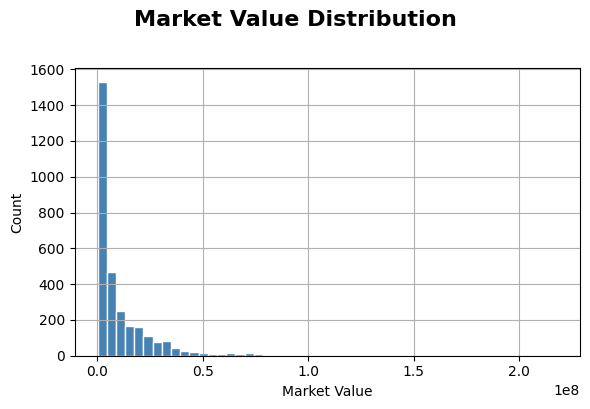

In [20]:
df['market_value'].hist(figsize=(6,4), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Market Value Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.xlabel('Market Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Our target variable is skewed.  We will want to convert it to log before modeling.

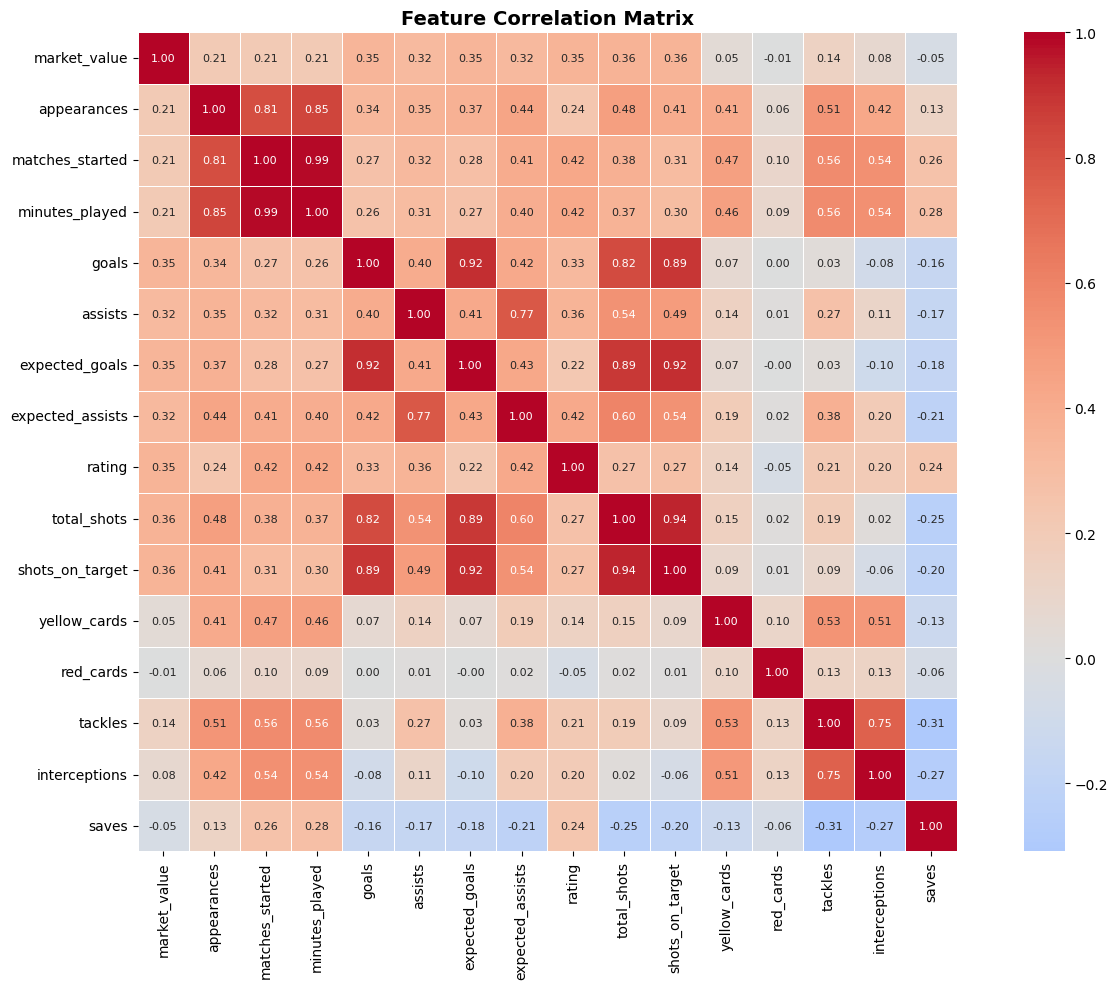

In [21]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size':8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# minutes_played is highly correlated with appearances and matches_started.  we'll drop them as minutes_played is more granular
df = df.drop(columns=['matches_started', 'appearances'])

In [23]:
# shots_on_target is highly correlated with goals, expected_goals, and total_shots.  we'll drop shots_on_target as the other
#  features are more important
# NOTE: expected_goals is also highly correlated with goals.  However, they are both important features from
#  a domain perspective.  Players who outperform their expected goals are probably worth more.  We'll keep both.
df = df.drop(columns=['shots_on_target'])

## Feature Engineering

In [24]:
# Add a column for the log of market_value because the data for that column is skewed.
df['log_market_value'] = np.log1p(df['market_value'])

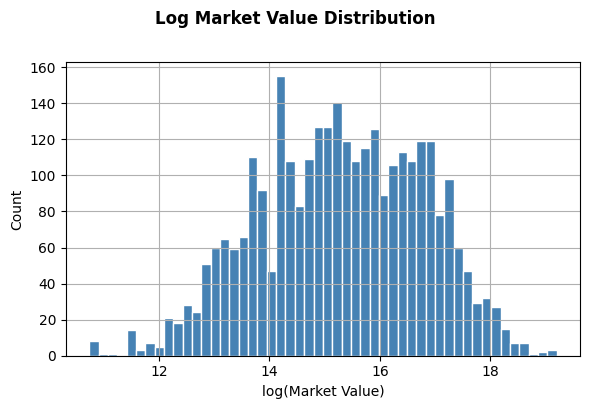

In [25]:
# Plot the log_market_value
df['log_market_value'].hist(figsize=(6,4), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Log Market Value Distribution', fontsize=12, fontweight='bold', y=1.01)
plt.xlabel('log(Market Value)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('images/log_market_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Introduce per-90-minute features.  These will help distinguish players who had higher stats simply 
#  because they played longer. We could, instead, introduce log-value columns, but per-90 (or per-game)
#  is a common approach to sports-stats modeling.  
per_90_cols = [
    'goals', 'assists', 'expected_goals', 'expected_assists',
    'total_shots', 'tackles', 'interceptions', 'yellow_cards',
    'red_cards', 'saves'
]
for col in per_90_cols:
    df[f'{col}_per90'] = df[col]/(df['minutes_played']/90)

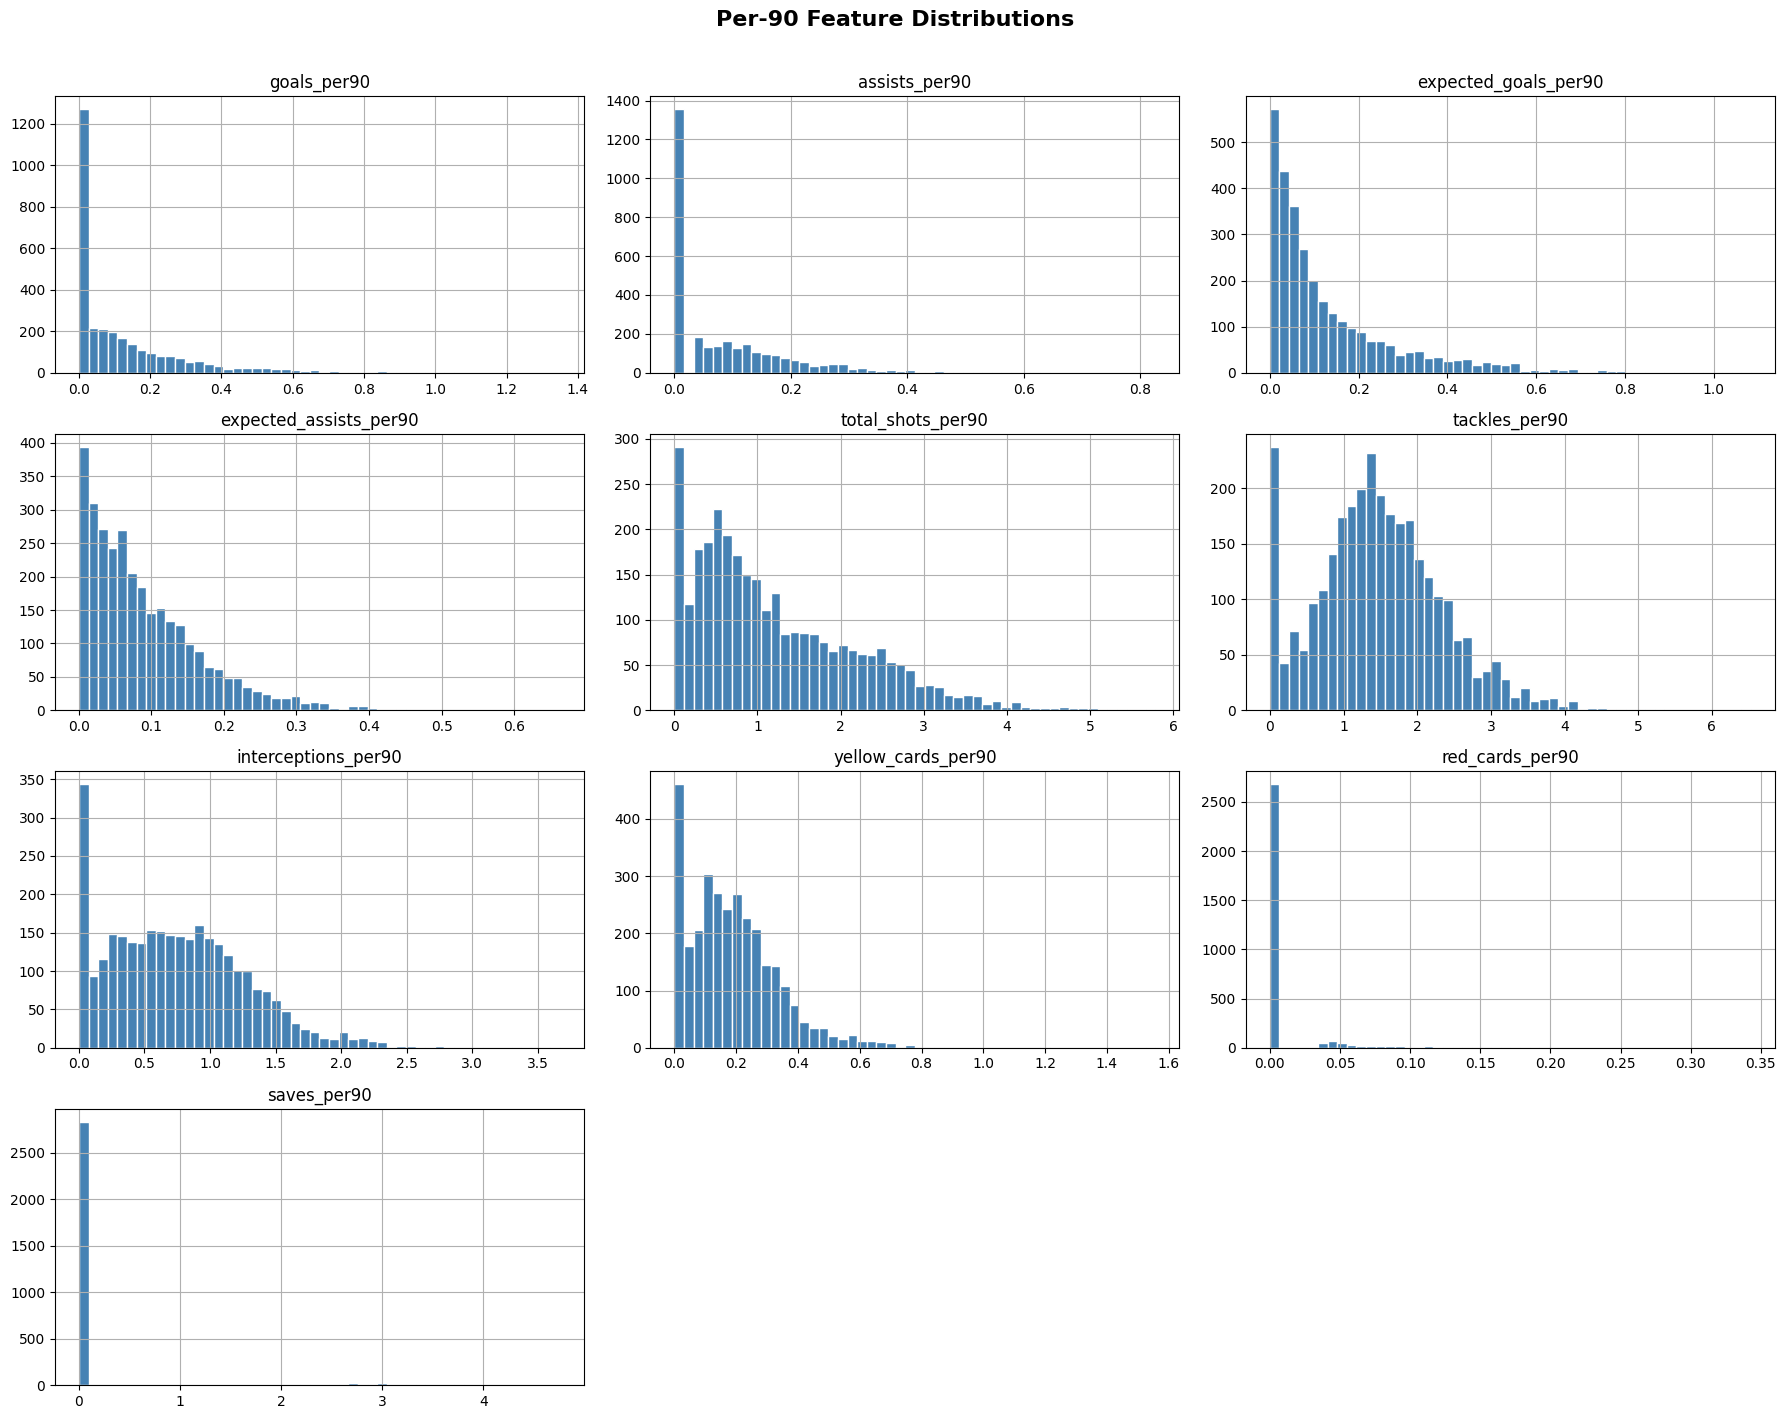

In [27]:
# Generate distribution graphs of per-90 features
per_90_cols = [c for c in df.columns if c.endswith('_per90')]
df[per_90_cols].hist(figsize=(18,14), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Per-90 Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# Drop columns that we've converted to log values or converted to 90-minute versions
df = df.drop(columns=[
    'goals', 'assists', 'expected_goals', 'expected_assists',
    'total_shots', 'tackles', 'interceptions', 'yellow_cards',
    'red_cards', 'saves', 'market_value'])
df.columns.tolist()

['league',
 'position',
 'minutes_played',
 'rating',
 'log_market_value',
 'goals_per90',
 'assists_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'total_shots_per90',
 'tackles_per90',
 'interceptions_per90',
 'yellow_cards_per90',
 'red_cards_per90',
 'saves_per90']

In [29]:
# Check for and remove outliers in our target
def flag_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)

outliers = flag_outliers(df, 'log_market_value')
print(f"Outliers found: {outliers.sum()}")
df = df[~outliers]
print(f"Rows remaining: {len(df)}")

Outliers found: 4
Rows remaining: 3054


## Modeling

In [30]:
# Separate our data into features and target
y = df['log_market_value']
X = df.drop(columns=['log_market_value'])

In [31]:
# Split columns by type
categorical_cols = ['league', 'position']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

In [32]:
# Split the data into train and test sets.  Build the column transformer for scaling and category encoding
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This also shuffles the data before splitting

# Initialize results DF
results = pd.DataFrame(
    index=['Lasso', 'Ridge', 'XGBoost', 'RandomForest'],
    columns=['R^2', 'MAE', 'RMSE']
)

### Evaluation Metric
We'll use R^2 as our evaluation metric as it measures the variance in player market value that is explained by the model and more directly answers the core project objective.

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Create and train model.
def fit_model(
    model, # The model to fit
    param_grid, # The parameters to search over with GridSearchCV
    model_name, # The name of the model (for logging and storing results)
    X_train_, # Local versions of data (for code re-use)
    X_test_,
    y_train_,
    y_test_,
    X, 
    y,
    results # The collection to add the results to
):
    preprocessor = ColumnTransformer([
        ('num', RobustScaler(), numerical_cols), # Use RobustScaler to reduce the influence of outliers
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])
    
    pipe = Pipeline([
        ('pre', preprocessor),
        ('model', model)
    ])
    
    # Use KFold so we shuffle before creating the k-fold splits
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        pipe, 
        param_grid, 
        cv=kfold, 
        scoring='r2', # R2 gives an indication of how the model explains variance
        n_jobs=-1 # Use all cpu cores to speed up search
    )
    grid.fit(X_train_, y_train_)

    # Calculate model metrics against the test set
    y_pred_log = grid.predict(X_test_)
    
    # Convert from log(market_value) back to market_value
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test_)
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

    results.loc[model_name, 'R^2'] = round(grid.best_score_, 3)
    results.loc[model_name, 'MAE'] = round(mae, 3)
    results.loc[model_name, 'RMSE'] = round(rmse, 3)
    
    return grid

### Lasso Model

In [34]:
categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.0001, 0.001, 0.01]
}
lasso = fit_model(Lasso(), param_grid, 'Lasso', 
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {lasso.best_params_}")
results.loc[['Lasso']]

Best Parameters: {'model__alpha': 0.0001}


,R^2,MAE,RMSE
Lasso,0.518,7050816.161,13684362.821


### Ridge model

In [35]:

categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.1, 1, 10]
}
ridge = fit_model(Ridge(), param_grid, 'Ridge',  
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {ridge.best_params_}")
results.loc[['Ridge']]

Best Parameters: {'model__alpha': 1}


,R^2,MAE,RMSE
Ridge,0.518,7052740.593,13671180.27


### XGBoost model

In [36]:
from xgboost import XGBRegressor
categorical_cols = ['league', 'position']
param_grid = {
    'model__n_estimators': [100, 125, 150],
    'model__max_depth': [1, 2, 3],
    'model__learning_rate': [0.085, 0.1, 0.15],
    'model__subsample': [0.6, 0.7, 0.8]
}
xgboost = fit_model(XGBRegressor(random_state=42), param_grid, 'XGBoost', 
                    X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {xgboost.best_params_}")
results.loc[['XGBoost']]

Best Parameters: {'model__learning_rate': 0.085, 'model__max_depth': 2, 'model__n_estimators': 150, 'model__subsample': 0.8}


,R^2,MAE,RMSE
XGBoost,0.514,7299932.581,14675677.786


### Random Forest model

In [37]:
from sklearn.ensemble import RandomForestRegressor
categorical_cols = ['league', 'position']
param_grid = {
   'model__n_estimators': [550, 600, 650],
    'model__max_depth': [7, 10, 13],
    'model__min_samples_split': [30, 40, 50]
}
rf = fit_model(RandomForestRegressor(random_state=42), param_grid, 'RandomForest', 
               X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {rf.best_params_}")
results.loc[['RandomForest']]

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 40, 'model__n_estimators': 600}


,R^2,MAE,RMSE
RandomForest,0.502,7306751.664,15531570.226


### Modeling results

In [38]:
results

,R^2,MAE,RMSE
Lasso,0.518,7050816.161,13684362.821
Ridge,0.518,7052740.593,13671180.27
XGBoost,0.514,7299932.581,14675677.786
RandomForest,0.502,7306751.664,15531570.226


These results aren't great.  MAE of 7 million euros means that for a low-value player of 500k, our estimate is way off.  For a high-value player of 50M+ euros, we aren't too far off, though.  Per-position modeling may be more accurate as stats like `saves` is important for goalies, but not for `forwards`.

### Per-position Modeling

In [39]:
# Split our data by position and model each separately
from sklearn.preprocessing import RobustScaler

categorical_cols = ['league']

for pos in df['position'].unique():
    df_pos = df[df['position'] == pos]
    X_pos = df_pos.drop(columns=['log_market_value', 'position'])
    y_pos = df_pos['log_market_value']
    X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(
        X_pos, y_pos, test_size=0.1, random_state=42
    )
    print(f"Training {pos} with {len(df_pos)} rows")
    
    results_pos = pd.DataFrame(
        index=['Lasso', 'Ridge', 'XGBoost'],
        columns=['R^2', 'MAE', 'RMSE']
    )
    # Train Lasso
    param_grid = {
        'model__alpha': [0.00001, 0.0001, 0.001, 0.1]
    }
    lasso_pos = fit_model(Lasso(), param_grid, 'Lasso', X_train_pos, X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best Lasso Parameters: {lasso_pos.best_params_}")

    # Train Ridge
    param_grid = {
        'model__alpha': [0.1, 1, 10]
    }
    ridge_pos = fit_model(Ridge(), param_grid, 'Ridge',  X_train_pos, X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best Ridge Parameters: {ridge_pos.best_params_}")

    param_grid = {
        'model__n_estimators': [25, 50, 100, 150, 200, 250],
        'model__max_depth': [1, 2, 3],
        'model__learning_rate': [0.85, 0.1, 0.15, 0.2],
        'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0]
    }
    xgboost_pos = fit_model(XGBRegressor(random_state=42), param_grid, 'XGBoost', X_train_pos, 
                            X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best XGBoost Parameters: {xgboost_pos.best_params_}")

    print(results_pos)
    print()
    

Training F with 606 rows
Best Lasso Parameters: {'model__alpha': 0.0001}
Best Ridge Parameters: {'model__alpha': 0.1}
Best XGBoost Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__n_estimators': 200, 'model__subsample': 0.8}
           R^2          MAE          RMSE
Lasso    0.516  7689275.889  19826607.802
Ridge    0.516  7700422.352  19823383.379
XGBoost  0.499  8065106.361  20708480.695

Training M with 1182 rows
Best Lasso Parameters: {'model__alpha': 0.001}
Best Ridge Parameters: {'model__alpha': 1}
Best XGBoost Parameters: {'model__learning_rate': 0.15, 'model__max_depth': 1, 'model__n_estimators': 150, 'model__subsample': 0.9}
           R^2          MAE          RMSE
Lasso    0.563  6131941.591  14296305.724
Ridge    0.563  6138977.113  14282495.965
XGBoost  0.564  6690932.249  16220468.253

Training D with 1041 rows
Best Lasso Parameters: {'model__alpha': 0.001}
Best Ridge Parameters: {'model__alpha': 1}
Best XGBoost Parameters: {'model__learning_rate':

Per-position modeling is only slightly better for midfielders, and it's worse for other positions.  This is most likely due to the small data set size after splitting it into position subgroups.  We'll stick with a single model as it has better overall performance and is simpler to work with.

### Feature Importance

In [40]:
# Get feature names after one-hot encoding
def find_feature_names(model):
    categorical_cols = ['league', 'position']
    ohe_features = model.best_estimator_['pre'].transformers_[1][1].get_feature_names_out(categorical_cols)
    return numerical_cols + list(ohe_features)

# Build coefficient series sorted by absolute magnitude
lasso_coefs = pd.Series(
    lasso.best_estimator_['model'].coef_,
    index=find_feature_names(lasso)
).sort_values(key=abs, ascending=False)

print(lasso_coefs.to_string())

league_Eredivisie        -1.351452
league_Premier League     1.306214
red_cards_per90           1.236447
position_G                1.127179
league_Liga Portugal     -1.114255
league_Super Lig         -1.092128
saves_per90              -0.591264
rating                    0.512439
minutes_played            0.372148
league_Serie A            0.336774
position_F               -0.331865
total_shots_per90         0.330890
league_Bundesliga         0.264057
expected_goals_per90      0.151106
position_M               -0.105662
yellow_cards_per90       -0.095699
assists_per90             0.094531
interceptions_per90      -0.075849
goals_per90              -0.072628
tackles_per90             0.047185
expected_assists_per90    0.038122
league_LaLiga             0.009534
position_D                0.007227
league_Ligue 1           -0.000000


The Lasso coefficients show us the most important features that impact market value.  Overall, player league is the most important.  Red cards are hightly impactful suggesting that aggressive players are valued more.  Goalies are also valued highly.

### Audit
Next, we will audit the most inaccurately modeled players.  This may give us insight into where our model is lacking.

In [41]:
# Generate predictions for all players using the given model
def print_innaccurate_predictions(model):
    y_pred_log = model.best_estimator_.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y)
      
    # Calculate the percent difference between the predicted and actual market value
    audit = df[['position', 'league']].copy()
    audit['actual_value'] = y_actual.values
    audit['predicted_value'] = y_pred
    audit['difference'] = audit['predicted_value'] - audit['actual_value']
    audit['percent_diff'] = (audit['difference'] / audit['actual_value']) * 100
    
    audit['actual_value_formatted'] = audit['actual_value'].apply(format_value)
    audit['predicted_value_formatted'] = audit['predicted_value'].apply(format_value)
    audit['percent_diff_formatted'] = audit['percent_diff'].apply(lambda x: f'{x:+.1f}%')
    
    # Join back with the original table that contains the player names
    audit = audit.join(df_profiles[['player_id', 'name']].set_index('player_id'), how='left')
    
    # Print results
    display_cols = ['name', 'position', 'league', 'actual_value_formatted', 
                    'predicted_value_formatted', 'percent_diff_formatted']
    print("Most Undervalued Players (model predicts higher market_value than actual)")
    print(audit.nlargest(15, 'percent_diff')[display_cols].to_string(index=False))
    
    print()
    print("Most Overvalued Players (model predicts lower market_value than actual)")
    print(audit.nsmallest(15, 'percent_diff')[display_cols].to_string(index=False))

# Format the given value to be more readable
def format_value(val):
    if val >= 1_000_000:
        return f'{val/1_000_000:.1f}M'
    return f'{val/1_000:.1f}K'

In [42]:
# Print out the most innacurately predicted player salaries using the ridge model, which is the most accurate so far
print_innaccurate_predictions(ridge)

Most Undervalued Players (model predicts higher market_value than actual)
            name position         league actual_value_formatted predicted_value_formatted percent_diff_formatted
     Karl Darlow        G Premier League                 210.0K                     13.0M               +6096.6%
            Nenê        F  Liga Portugal                  52.0K                      3.2M               +6021.2%
 Marius Courcoul        D        Ligue 1                  53.0K                      2.6M               +4850.8%
 Stephan Zagadou        D        Ligue 1                  97.0K                      3.5M               +3532.6%
           Josan        M         LaLiga                 105.0K                      3.7M               +3387.8%
   Matías Dituro        G         LaLiga                 205.0K                      6.5M               +3057.5%
          Bebeto        D  Liga Portugal                  53.0K                      1.6M               +2827.4%
   Santi Cazorla      

From the audit, we can see a larger driver of the modeling innacuracies is age of the player. The Undervalued Players table mainly contains players aged 34 to 42.  These older players are at the end of their careers and thus have a lower market value becuase their performance is expected to degrade or they will retire soon.  The Overvalued Players table contains entirely players less than 28 years old.  These are players with high established performance and many years left in their careers, thus increasing their value.  This finding is corroborated from the Transfermarkt research website, which contains stat on Soccer players.  Their article [Transfermarkt Market Value explained - How is it determined?](https://www.transfermarkt.co.in/transfermarkt-market-value-explained-how-is-it-determined-/view/news/385100) lists the top two most important factors are future prospects and age.  

# Improving Modeling Performance with Player Age
Given this gap, a script was created to download dates of birth from wikipedia and create a new data set that we can join that with our existing data and retrain the models.

### Age EDA

In [43]:
df_birth_years = pd.read_csv('data/player_birth_years.csv')
df_birth_years.head()

,player_id,name,birth_year
0,804508,Viktor Gyökeres,1998.0
1,934235,Bukayo Saka,2001.0
2,794839,Gabriel Jesus,1997.0
3,922573,Gabriel Martinelli,2001.0
4,836705,Kai Havertz,1999.0


In [44]:
df_birth_years.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4682 entries, 0 to 4681
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   player_id   4682 non-null   int64  
 1   name        4682 non-null   object 
 2   birth_year  4394 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 109.9+ KB


In [45]:
df_birth_years.describe()

,player_id,birth_year
count,4.682000e+03,4394.000000
mean,1.046369e+06,1998.565772
std,5.427390e+05,6.859016
min,7.910000e+02,1960.000000
25%,8.275198e+05,1996.000000
50%,9.960380e+05,2000.000000
75%,1.402696e+06,2003.000000
max,2.544201e+06,2010.000000


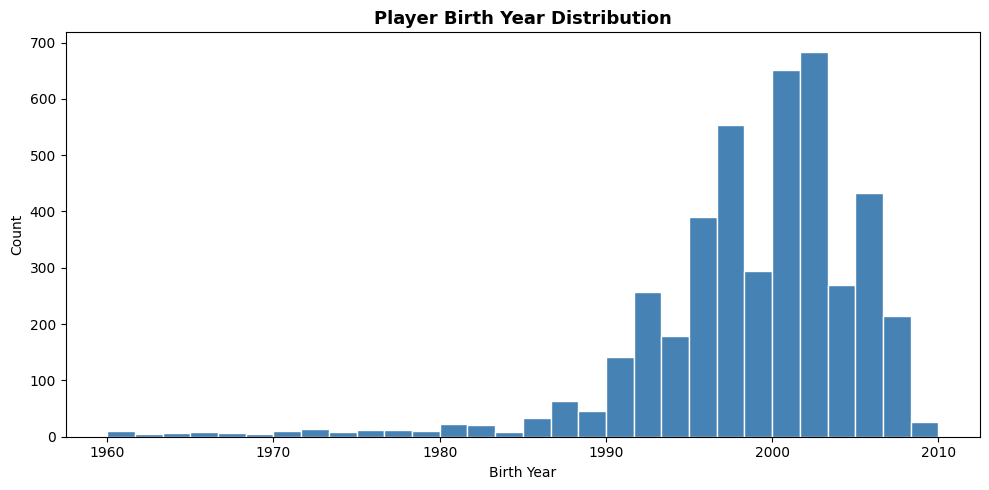

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(df_birth_years['birth_year'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Player Birth Year Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Birth Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The age distribution shows birth years going back to 1960.  This is probably due to multiple people with the same name.  Our wikipedia script isn't advanced enough to be able to disambiguate.  We'll drop any rows with birth year less than 1985.

### Age Data Cleaning and Feature Engineering

In [47]:
from datetime import datetime

# Drop rows with no birth year
df_birth_years = df_birth_years.dropna()

# Drop rows with suspect birth years
df_birth_years = df_birth_years[df_birth_years['birth_year'] >= 1985]

# Convert birth year to age for modeling
current_year = datetime.now().year
df_birth_years['age'] = current_year - df_birth_years['birth_year']

# Add a squared age feature as it may help the model understand any non-linear characteristics of age
df_birth_years['age_squared'] = df_birth_years['age'] ** 2

# Drop columns that are no longer needed
df_birth_years = df_birth_years.drop(columns=['name', 'birth_year'])

In [48]:
df = pd.merge(df, df_birth_years, on='player_id', how='inner').set_index('player_id')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2994 entries, 804508 to 283847
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   league                  2994 non-null   object 
 1   position                2994 non-null   object 
 2   minutes_played          2994 non-null   int64  
 3   rating                  2994 non-null   float64
 4   log_market_value        2994 non-null   float64
 5   goals_per90             2994 non-null   float64
 6   assists_per90           2994 non-null   float64
 7   expected_goals_per90    2994 non-null   float64
 8   expected_assists_per90  2994 non-null   float64
 9   total_shots_per90       2994 non-null   float64
 10  tackles_per90           2994 non-null   float64
 11  interceptions_per90     2994 non-null   float64
 12  yellow_cards_per90      2994 non-null   float64
 13  red_cards_per90         2994 non-null   float64
 14  saves_per90             2994 non-null 

Re-split our data and retrain our models.

## Modeling

In [50]:
# Separate our data into features and target
y = df['log_market_value']
X = df.drop(columns=['log_market_value'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This also shuffles the data before splitting

# Split columns by type
categorical_cols = ['league', 'position']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# Initialize results DF
results = pd.DataFrame(
    index=['Lasso', 'Ridge', 'XGBoost', 'RandomForest'],
    columns=['R^2', 'MAE', 'RMSE']
)

### Lasso model

In [51]:
categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.0001, 0.001, 0.01]
}
lasso = fit_model(Lasso(), param_grid, 'Lasso', 
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {lasso.best_params_}")
results.loc[['Lasso']]

Best Parameters: {'model__alpha': 0.0001}


,R^2,MAE,RMSE
Lasso,0.641,6458487.4,13732762.048


### Ridge Model

In [52]:
categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.01, 0.1, 1]
}
ridge = fit_model(Ridge(), param_grid, 'Ridge',  
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {ridge.best_params_}")
results.loc[['Ridge']]

Best Parameters: {'model__alpha': 0.1}


,R^2,MAE,RMSE
Ridge,0.641,6459478.199,13735416.694


### XGBoost model

In [53]:
from xgboost import XGBRegressor
categorical_cols = ['league', 'position']
param_grid = {
    'model__n_estimators': [300, 325, 350],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.02, 0.03, 0.04],
    'model__subsample': [0.2, 0.3, 0.4]
}
xgboost = fit_model(XGBRegressor(random_state=42), param_grid, 'XGBoost', 
                    X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {xgboost.best_params_}")
results.loc[['XGBoost']]

Best Parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 325, 'model__subsample': 0.3}


,R^2,MAE,RMSE
XGBoost,0.648,6391325.905,13559845.583


### Random Forest model

In [54]:
from sklearn.ensemble import RandomForestRegressor
categorical_cols = ['league', 'position']
param_grid = {
   'model__n_estimators': [250, 300, 350],
    'model__max_depth': [15, 20, 25],
    'model__min_samples_split': [2, 5]
}
rf = fit_model(RandomForestRegressor(random_state=42), param_grid, 'RandomForest', 
               X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {rf.best_params_}")
results.loc[['RandomForest']]

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 300}


,R^2,MAE,RMSE
RandomForest,0.618,6526272.912,14497379.155


### Modeling Results

In [55]:
results

,R^2,MAE,RMSE
Lasso,0.641,6458487.4,13732762.048
Ridge,0.641,6459478.199,13735416.694
XGBoost,0.648,6391325.905,13559845.583
RandomForest,0.618,6526272.912,14497379.155


As we predicted, age is a significant factor in a player's salary.  Including the age raised our best model performance by an R^2 of 0.130 up to 0.648.  

In [56]:
# Determine the most important factors.  Use the Lasso model as it gives the most interpretable 
#  information and its performance wasn't much worse than XGBoost.
lasso_coefs = pd.Series(
    lasso.best_estimator_['model'].coef_,
    index=find_feature_names(lasso)
).sort_values(key=abs, ascending=False)

print(lasso_coefs.to_string())

age_squared              -2.127744
position_G                2.007737
age                       1.499214
league_Eredivisie        -1.376715
league_Premier League     1.296121
red_cards_per90           1.060017
league_Liga Portugal     -1.041527
league_Super Lig         -0.899935
saves_per90              -0.841089
rating                    0.562461
minutes_played            0.393148
league_Serie A            0.347362
position_F               -0.343574
expected_goals_per90      0.317377
league_Bundesliga         0.196813
league_LaLiga             0.145716
position_M               -0.102052
total_shots_per90         0.099934
expected_assists_per90    0.097644
goals_per90              -0.096044
assists_per90             0.078736
interceptions_per90      -0.046425
yellow_cards_per90       -0.043611
tackles_per90            -0.031994
league_Ligue 1           -0.000000
position_D                0.000000


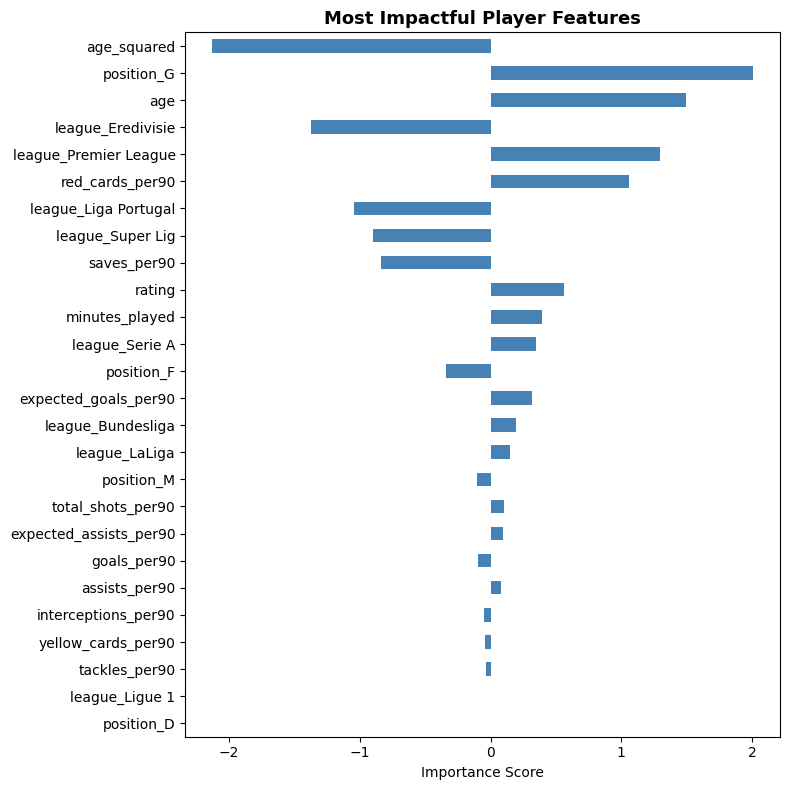

In [57]:
plt.figure(figsize=(8, 8))
lasso_coefs.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Most Impactful Player Features', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/feature_importance', dpi=150, bbox_inches='tight')
plt.show()

### Breakdown of Feature Importance

**Age -** Looking at the features ranked by importance, we see just how much player age impacts market value.  Interestingly, the square of age is a large negative impact while the age itself is a large positive impact.  This indicates a U-shape to the data where both relatively old and relatively young players are valued much less while players in the middle of their careers are valued more.  

**Position -** Goalies are highly valued, but other positions have a much smaller impact on market value, with defenders having no impact.  Also interesting is that saves per 90 has a relatively large negative impact while goalies have a high positive impact.  This may be be because a large number of saves indicates many shots-on-goal from the opposing team and therefore the player is on a weaker team, and thus has a lower market value.  This implies that goalies with a large number of saves, and are thus highly-performing, may be undervalued.  

**Rating -** Player rating, a comprehensive value of a player's performance, has only a moderate impact.  This, more than anything else, reinforces just how little player performance impacts market value.

**Minutes Played -** Minues played also has a moderate positive impact as players with more experience are more valued.

**Per 90 -** Red cards per 90 has a large positive impact, suggesting that aggressive players are highly valued.  Saves per 90 has a large negative impact, as discussed above.  The other per 90 performance features had very little impact on player market value.  This may be because of their moderate correlation with rating.

**League -** The impact of league follows exactly what we would expect given the league rankings.  Premier league is a the top, and has the highest positive impact on market value.  Eredivisie is at the bottom and has the largest negative impact.  The other leagues contribute based on their position in the ranking as well.

The remaining variance can be attributed to other off-field factors that did not exist in the data set.

## Summary of Findings
Our regression model achieves an R^2 of 0.648, meaning that our data set of performance statistics, position, age, and league together explain approximately 65% of the variance in Transfermarkt player market values.  The remaining 35% can be attributed to other off-field features not present in our data set as well as noise and modeling imperfections.  

Feature importance analysis shows that league membership and age are dominant factors, with on-field performance having a lesser impact.  Given that our data set includes comprehensive performance features, we can infer that players whose actual market value significantly differs from their model predicted value are likely priced more heavily on non-performance factors outside of our data set than on factors that would directly affect the outcome of a game.  This is particularly true for players on both the lower and upper end of the age spectrum, where our model shows market value is disproportionately influenced.

## Players to Investigate
With the findings above, we can search our data set for players that we should target for further investigation.  These players should have a high rating, indicating that they have good on-field performance.  They should also be on the upper or lower end of the age spectrum, which we know from our modeling are under-valued players.  Finally, they should have a relatively large difference in actual vs predicted market value, which we've concluded means their value is impacted by off-field factors not in our data set.

In [60]:
# Define thresholds
young_threshold = df['age'].quantile(0.25)
old_threshold = df['age'].quantile(0.75)
min_rating = df['rating'].quantile(0.99)
min_pct_diff = 25.0
print(f"Young threshold: {young_threshold:.0f}")
print(f"Old threshold: {old_threshold:.0f}")
print(f"Rating threshold: {min_rating:.3f}")

# Generate predictions
y_pred_log = xgboost.best_estimator_.predict(X)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y)

candidates = df.copy()
candidates = candidates.reset_index().merge(
    df_profiles[['player_id', 'name']],
    on='player_id',
    how='left'
).set_index('player_id')

candidates['actual_value'] = y_actual.values
candidates['predicted_value'] = y_pred
candidates['pct_diff'] = (candidates['predicted_value'] - candidates['actual_value']) / candidates['actual_value'] * 100
candidates['actual_value_fmt'] = candidates['actual_value'].apply(format_value)
candidates['predicted_value_fmt'] = candidates['predicted_value'].apply(format_value)
candidates['pct_diff_fmt'] = candidates['pct_diff'].apply(lambda x: f'{x:+.1f}%')

targets = candidates[
    ((candidates['age'] <= young_threshold) | (candidates['age'] >= old_threshold)) &
    (candidates['rating'] >= min_rating) &
    (candidates['pct_diff'] >= min_pct_diff)
].copy()

display_cols = ['name', 'position', 'league', 'age', 'rating', 'actual_value_fmt', 'predicted_value_fmt', 'pct_diff_fmt']

print(targets.nlargest(20, 'rating')[display_cols].to_string(index=False))

Young threshold: 24
Old threshold: 30
Rating threshold: 7.462
            name position        league  age   rating actual_value_fmt predicted_value_fmt pct_diff_fmt
   Lionel M'Pasi        G       Ligue 1 32.0 7.825000           370.0K              630.3K       +70.4%
    Yan Diomande        F    Bundesliga 20.0 7.692593            49.0M               61.4M       +25.3%
   Rémy Descamps        G       Ligue 1 30.0 7.660000             1.9M                4.6M      +144.4%
     Luka Modrić        M       Serie A 41.0 7.568966             4.4M                6.9M       +57.0%
Ronald Koeman Jr        G    Eredivisie 31.0 7.496429           595.0K                1.3M      +111.6%
Nicolás Otamendi        D Liga Portugal 38.0 7.483333             1.1M                1.6M       +44.6%


A club looking to make performanced-based recruitment decisions should look further into the above players as they are most likely under-valued given their on-field performance.